2026-06-30 23:57:22,677 [INFO] Tentando ler o arquivo de dados: /kaggle/input/seu-dataset/dadosTextosCientificos.tsv
2026-06-30 23:57:22,678 [WARNING] O arquivo /kaggle/input/seu-dataset/dadosTextosCientificos.tsv NÃO foi encontrado no Kaggle!
2026-06-30 23:57:22,679 [INFO] Executando gerador de dados robusto de contingência (80 documentos).



 INICIANDO PIPELINE ANALÍTICO E MOTOR DOCUMENTAL 



2026-06-30 23:57:23,158 [INFO] Lematizando textos e extraindo entidades... (Pode demorar uns segundos)


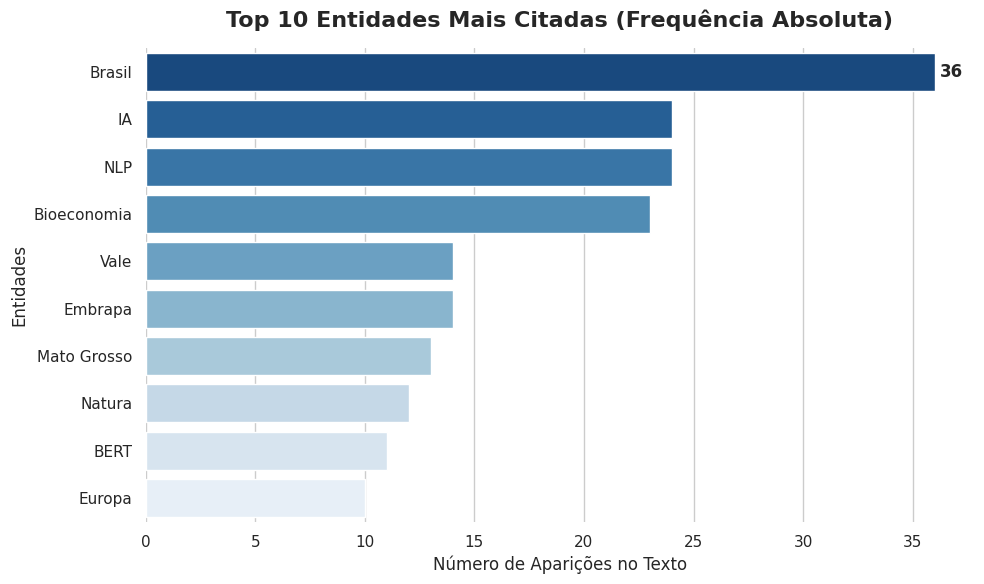

2026-06-30 23:57:23,959 [INFO] Gráfico 01 (Entidades) exibido com sucesso!
2026-06-30 23:57:23,960 [INFO] Vetorizando os textos (SBERT)...
2026-06-30 23:57:23,965 [INFO] No device provided, using cuda:0
2026-06-30 23:57:24,011 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-30 23:57:24,018 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
2026-06-30 23:57:24,036 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-30 23:57:24,043 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-06-30 23:57:24,561 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-30 23:57:24,585 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-06-30 23:57:24,609 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-06-30 23:57:24,631 [INFO] HTTP Request: HEAD https://huggingface.c


--- PALAVRAS-CHAVE QUE DEFINEM CADA CLUSTER ---
Cluster 0: Geral
Cluster 1: agronegócio, esg, verde, vale, mato
Cluster 2: verde, esg, agronegócio, grosso, mato


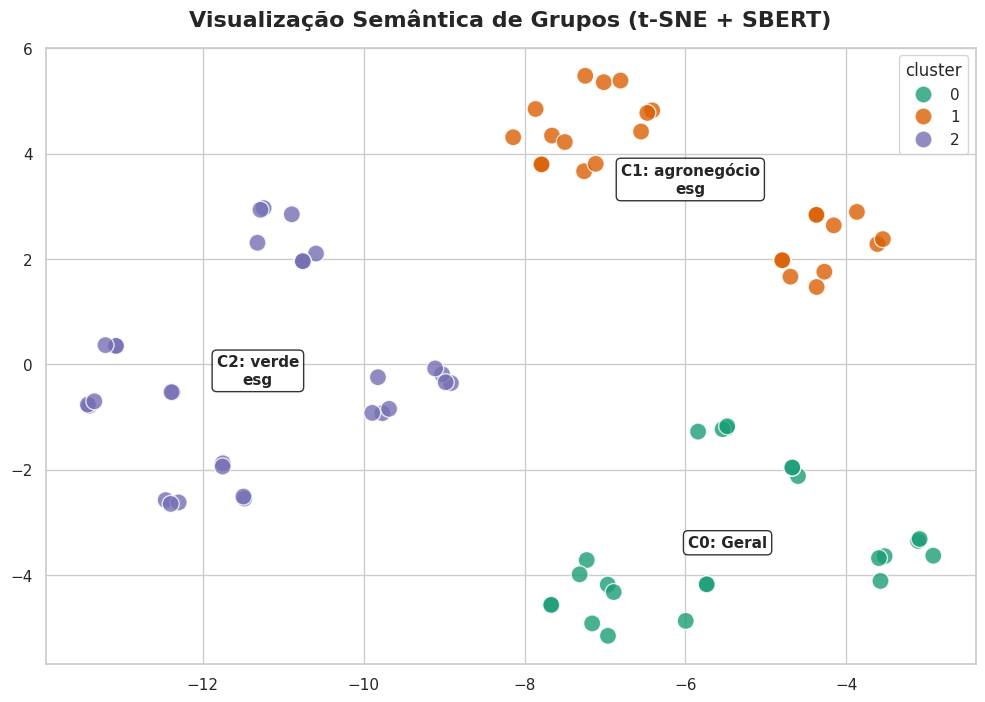

2026-06-30 23:57:27,412 [INFO] Gráfico 02 (Clusters Semânticos) exibido com sucesso!



Processamento completo!


In [6]:
# ==============================================================================
# PROJECT: MOTOR DE INTELIGÊNCIA DOCUMENTAL - ANALYTICS & VISUALIZATION (V4)
# ==============================================================================

import os
import logging
import random
from collections import Counter
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import spacy
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    print("Instalando dependências faltantes (Sentence Transformers)...")
    os.system("pip install -q sentence-transformers")
    from sentence_transformers import SentenceTransformer

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger("SeniorAnalytics")

# Configuração de estilo de gráficos do Seaborn para padrão executivo
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS (REAIS OU MOCK ROBUSTO)
# ==============================================================================
def generate_robust_mock_data(n=80) -> pd.DataFrame:
    temas = [
        ("Bioeconomia", ["Embrapa", "Amazônia", "Brasil", "Natura", "BNDES"], 
         ["A pesquisa avança na preservação da floresta.", "O uso de castanhas locais aumenta o PIB.", "Sustentabilidade verde é o futuro da região Norte."]),
        ("IA e NLP", ["Google Cloud", "AWS", "OpenAI", "Brasil", "São Paulo"], 
         ["Modelos Transformers como o BERT revolucionam buscas.", "Bancos vetoriais no cloud aceleram as consultas.", "Processamento de linguagem natural otimiza processos."]),
        ("Agronegócio ESG", ["Vale", "Mato Grosso", "Embrapa", "Europa", "Brasil"], 
         ["Exportação de soja e milho com selo verde.", "Sensores IoT ajudam os agricultores na colheita.", "Créditos de carbono atraem investimento estrangeiro."])
    ]
    
    data = []
    random.seed(42)
    for i in range(1, n+1):
        tema, entidades, frases = random.choice(temas)
        ent1 = random.choice(entidades + ["Brasil", "Embrapa", "Brasil"])
        ent2 = random.choice(entidades)
        frase1 = random.choice(frases)
        texto = f"{frase1} Iniciativas da {ent1} em parceria com {ent2} estão liderando a área de {tema}."
        data.append({"doc_id": i, "titulo": f"Artigo {i} - {tema}", "texto": texto, "categoria": tema})
        
    return pd.DataFrame(data)

def load_real_data(filepath: str) -> pd.DataFrame:
    logger.info(f"Tentando ler o arquivo de dados: {filepath}")
    if not os.path.exists(filepath):
        logger.warning(f"O arquivo {filepath} NÃO foi encontrado no Kaggle!")
        logger.info("Executando gerador de dados robusto de contingência (80 documentos).")
        return generate_robust_mock_data(n=80)

    df = pd.read_csv(filepath, sep='\t') 
    if 'texto' not in df.columns:
        for col in ['abstract', 'text', 'resumo']:
            if col in df.columns:
                df = df.rename(columns={col: 'texto'})
                break
    df['doc_id'] = range(1, len(df) + 1)
    df['texto'] = df['texto'].fillna('')
    logger.info(f"{len(df)} documentos carregados com sucesso.")
    return df

# ==============================================================================
# 2. NLP E RECONHECIMENTO DE ENTIDADES
# ==============================================================================
class DocumentProcessor:
    def __init__(self, model_name: str = "pt_core_news_sm"):
        try:
            self.nlp = spacy.load(model_name)
        except OSError:
            logger.info("Baixando biblioteca idiomática do Spacy...")
            spacy.cli.download(model_name)
            self.nlp = spacy.load(model_name)

    def process(self, text: str):
        doc = self.nlp(str(text))
        lemmas = [t.lemma_.lower() for t in doc if not t.is_stop and not t.is_punct and t.is_alpha]
        entities = [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in ["ORG", "LOC", "MISC"]]
        return " ".join(lemmas), entities

# ==============================================================================
# 3. EXTRAÇÃO DE PALAVRAS-CHAVE VIA TF-IDF E VETORIZAÇÃO SBERT
# ==============================================================================
def extract_cluster_keywords(df: pd.DataFrame, text_col: str, top_n: int = 5):
    logger.info("Extraindo vocabulário e palavras mais fortes por cluster (TF-IDF)...")
    
    cluster_texts = df.groupby('cluster')[text_col].apply(lambda x: ' '.join(x)).tolist()
    cluster_ids = df.groupby('cluster')['cluster'].first().tolist()
    
    try:
        vectorizer = TfidfVectorizer(max_df=0.9, min_df=2)
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        feature_names = vectorizer.get_feature_names_out()
        
        cluster_keywords = {}
        for i in range(len(cluster_texts)):
            doc_vector = tfidf_matrix[i].toarray().flatten()
            top_indices = doc_vector.argsort()[-top_n:][::-1]
            top_words = [feature_names[idx] for idx in top_indices if doc_vector[idx] > 0]
            cluster_keywords[cluster_ids[i]] = ", ".join(top_words) if top_words else "Geral"
            
        return cluster_keywords
    except ValueError:
        logger.warning("Corpus pequeno demais para gerar TF-IDF. Usando rótulos genéricos.")
        return {cid: "Geral" for cid in cluster_ids}

# ==============================================================================
# 4. PLOTS ANALÍTICOS EXIBIDOS DIRETAMENTE NO TERMINAL/NOTEBOOK
# ==============================================================================
def plot_top_entities(df: pd.DataFrame):
    all_entities = []
    for ent_list in df['entidades']:
        all_entities.extend([ent[0] for ent in ent_list])
        
    counter = Counter(all_entities)
    top_entities = counter.most_common(10)
    
    if not top_entities:
        logger.warning("Nenhuma entidade encontrada para plotar.")
        return
        
    ent_names = [x[0] for x in top_entities]
    ent_counts = [x[1] for x in top_entities]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=ent_counts, y=ent_names, hue=ent_names, palette="Blues_r", dodge=False, legend=False)
    ax.bar_label(ax.containers[0], padding=4, fontweight='bold')
    
    plt.title("Top 10 Entidades Mais Citadas (Frequência Absoluta)", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Número de Aparições no Texto")
    plt.ylabel("Entidades")
    
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    
    # EXIBE O GRÁFICO NA TELA EM VEZ DE SALVAR
    plt.show()
    logger.info("Gráfico 01 (Entidades) exibido com sucesso!")

def cluster_and_visualize(df: pd.DataFrame):
    logger.info("Vetorizando os textos (SBERT)...")
    model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    embeddings = model.encode(df['texto_limpo'].tolist(), show_progress_bar=False)
    
    n_clusters = min(3, len(df))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(embeddings)
    
    keywords_dict = extract_cluster_keywords(df, 'texto_limpo')
    print("\n--- PALAVRAS-CHAVE QUE DEFINEM CADA CLUSTER ---")
    for c_id, words in keywords_dict.items():
        print(f"Cluster {c_id}: {words}")
    
    perplexity = min(30, len(df) - 1) 
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    coords = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=df['cluster'], palette='Dark2', s=150, alpha=0.8)
    
    for c_id in range(n_clusters):
        cluster_points = coords[df['cluster'] == c_id]
        if len(cluster_points) > 0:
            center_x, center_y = cluster_points.mean(axis=0)
            
            palavras = [p for p in keywords_dict.get(c_id, "Geral").split(", ") if p.strip()]
            
            if len(palavras) >= 2:
                texto_legenda = f"C{c_id}: {palavras[0]}\n{palavras[1]}"
            elif len(palavras) == 1:
                texto_legenda = f"C{c_id}: {palavras[0]}"
            else:
                texto_legenda = f"C{c_id}: Geral"
            
            plt.annotate(
                texto_legenda, 
                (center_x, center_y),
                xytext=(0, 0), textcoords='offset points', 
                fontsize=11, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.8)
            )
            
    plt.title("Visualização Semântica de Grupos (t-SNE + SBERT)", fontsize=16, fontweight='bold', pad=15)
    
    # EXIBE O GRÁFICO NA TELA EM VEZ DE SALVAR
    plt.show()
    logger.info("Gráfico 02 (Clusters Semânticos) exibido com sucesso!")


# ==============================================================================
# ORQUESTRAÇÃO
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*70)
    print(" INICIANDO PIPELINE ANALÍTICO E MOTOR DOCUMENTAL ")
    print("="*70 + "\n")
    
    # 1. Carregar Base
    df_docs = load_real_data('/kaggle/input/seu-dataset/dadosTextosCientificos.tsv')
    
    # 2. Processar 
    processor = DocumentProcessor()
    logger.info("Lematizando textos e extraindo entidades... (Pode demorar uns segundos)")
    df_docs[['texto_limpo', 'entidades']] = df_docs['texto'].apply(
        lambda x: pd.Series(processor.process(x))
    )
    
    # 3. Plotar Gráfico de Barras Avançado (Aparecerá na tela)
    plot_top_entities(df_docs)
    
    # 4. Vetorizar, Agrupar e Plotar t-SNE (Aparecerá na tela)
    cluster_and_visualize(df_docs)
    
    print("\nProcessamento completo!")